# Step - 1 (Environment Setup)

In [ ]:
# For data manipulation
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For splitting data
from sklearn.model_selection import train_test_split

# For scaling data
from sklearn.preprocessing import StandardScaler

# For building models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# For evaluating models
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 2: Loading and Exploring the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

data_path = "/content/drive/MyDrive/Dataset"
print(f"Listing files in: {data_path}")

try:
  print(os.listdir(data_path))
except FileNotFoundError:
  print("Error: Folder not found. Did you add the shortcut to 'My Drive'?")

Listing files in: /content/drive/MyDrive/Dataset
['heart_cleveland_upload.csv']


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/heart_cleveland_upload.csv')

In [ ]:
print(df.head())

print(df.info())

print(df.isnull().sum())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       29

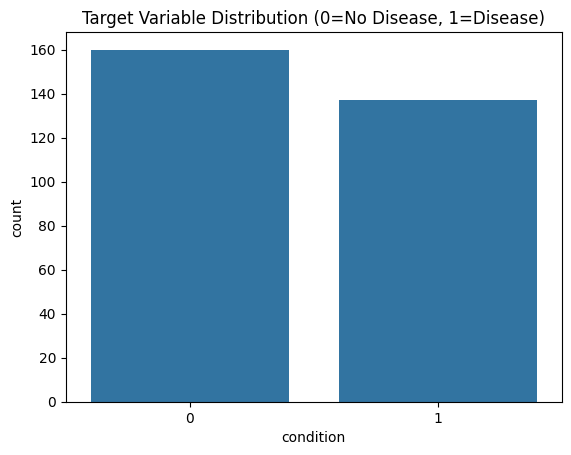

In [ ]:
sns.countplot(x='condition', data=df)
plt.title('Target Variable Distribution (0=No Disease, 1=Disease)')
plt.show()

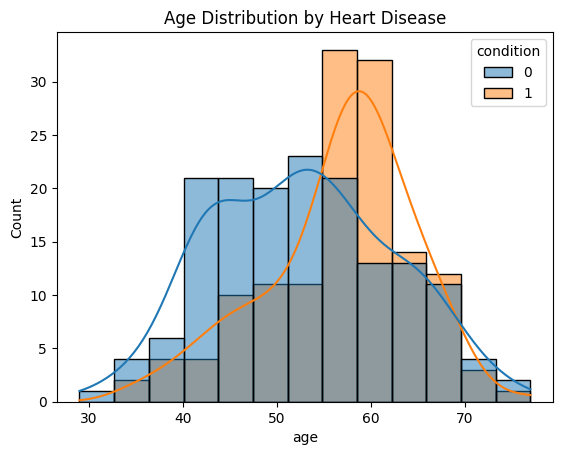

In [ ]:
sns.histplot(data=df, x='age', hue='condition', kde=True)
plt.title('Age Distribution by Heart Disease')
plt.show()

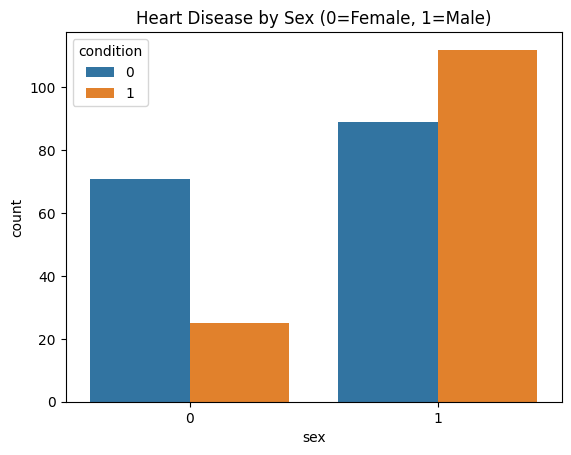

In [ ]:
sns.countplot(x='sex', hue='condition', data=df)
plt.title('Heart Disease by Sex (0=Female, 1=Male)')
plt.show()

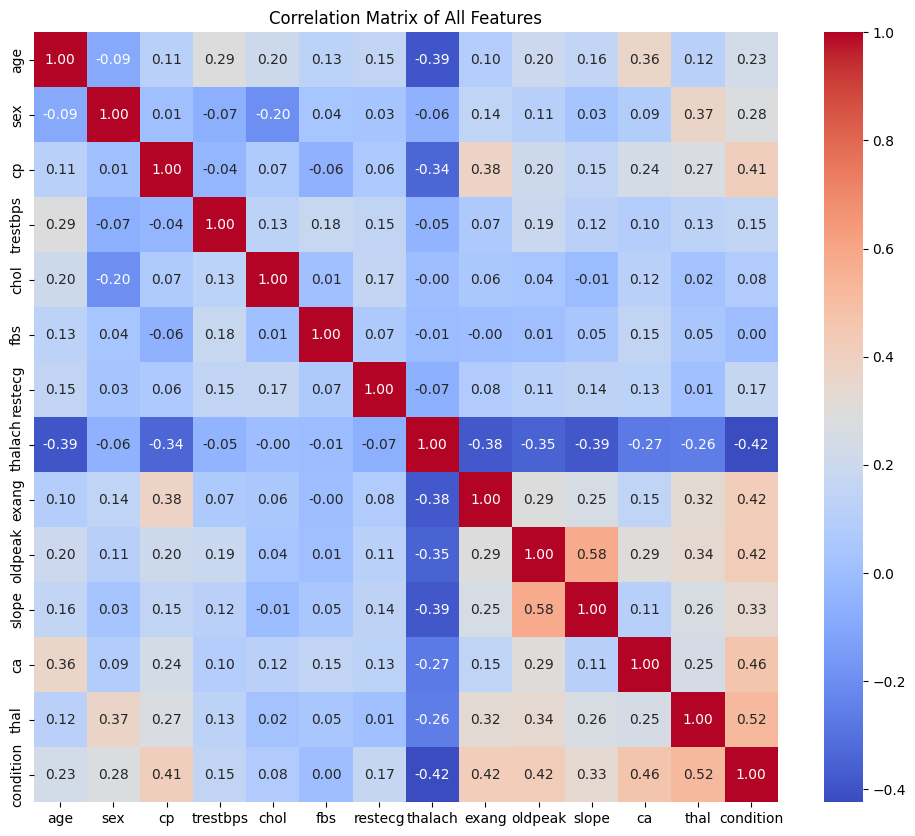

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of All Features')
plt.show()

# Step 3: Advanced Data Preprocessing for ALL Models

In [ ]:
# --- REVISED Step 3: Advanced Data Preprocessing for ALL Models ---

# 1. Define your Features (X) and Target (y)
# We need to make sure 'df' is loaded from Step 2.
# --- ADJUSTMENT 2: Drop Weak Features ---

# Revert to using ALL columns
X = df.drop('condition', axis=1)
# (Do NOT drop 'fbs')
y = df['condition']

# 2. One-Hot Encoding for Categorical Features
# Models like SVM and Logistic Regression need this to work best.
# Features: cp (Chest Pain), restecg (ECG results), slope (ST slope), thal (Thalassemia)
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Split the Data (80% Training, 20% Testing)
# We use stratify=y to make sure both sets have a balanced number of sick/healthy people
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling
# Essential for SVM, KNN, and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to keep column names (helpful for SHAP later)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Data Preprocessing Complete!")
print(f"Training Shape: {X_train_scaled.shape}")
print(f"Testing Shape: {X_test_scaled.shape}")

Data Preprocessing Complete!
Training Shape: (237, 18)
Testing Shape: (60, 18)


# Step 4: Training Individual Benchmark Models

In [ ]:
# --- Step 4: Training Individual Benchmark Models ---

from sklearn.svm import SVC
from xgboost import XGBClassifier

# Dictionary to store model results
model_scores = {}

# 1. Logistic Regression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)
model_scores['Logistic Regression'] = accuracy_score(y_test, log_pred)
print("Logistic Regression Trained.")

# 2. K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
model_scores['KNN'] = accuracy_score(y_test, knn_pred)
print("KNN Trained.")

# 3. Support Vector Machine (SVM)
# We set probability=True because the Stacking Classifier needs probabilities later
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
model_scores['SVM'] = accuracy_score(y_test, svm_pred)
print("SVM Trained.")

# 4. Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
model_scores['Random Forest'] = accuracy_score(y_test, rf_pred)
print("Random Forest Trained.")

# 5. XGBoost
# XGBoost often requires labels to be integers, but our y is already 0/1.
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)
model_scores['XGBoost'] = accuracy_score(y_test, xgb_pred)
print("XGBoost Trained.")

# --- Print the Comparison Table ---
print("\n--- Model Performance Comparison ---")
results_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Accuracy'])
print(results_df.sort_values(by='Accuracy', ascending=False))

Logistic Regression Trained.
KNN Trained.
SVM Trained.
Random Forest Trained.
XGBoost Trained.

--- Model Performance Comparison ---
                 Model  Accuracy
0  Logistic Regression  0.916667
1                  KNN  0.883333
2                  SVM  0.883333
4              XGBoost  0.883333
3        Random Forest  0.866667


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:47:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Step 5: Building the Stacking Ensemble

Training Stacking Ensemble...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:47:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:47:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:47:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:47:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:47:46] WARNING: /w


✅ Stacking Ensemble Accuracy: 0.8667

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        32
           1       1.00      0.71      0.83        28

    accuracy                           0.87        60
   macro avg       0.90      0.86      0.86        60
weighted avg       0.89      0.87      0.86        60



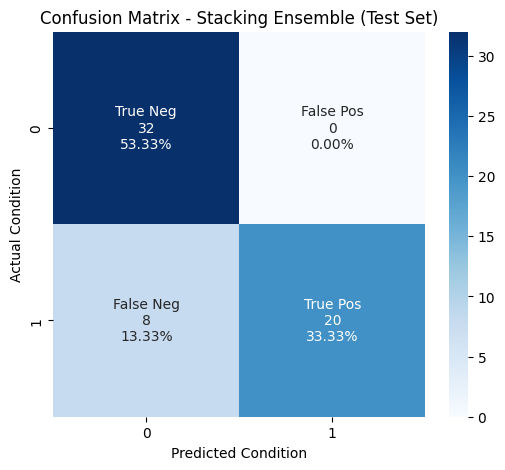

In [ ]:
# --- Step 5: Reverting to Stacking Ensemble ---

from sklearn.ensemble import StackingClassifier

# 1. Define Base Estimators
# We include LR, RF, XGB, and SVM
base_estimators = [
    ('lr', LogisticRegression(C=1.0, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=42))
]

# 2. Meta-Learner
# We keep it simple to avoid overfitting
meta_learner = LogisticRegression()

# 3. Build & Train
stacking_model = StackingClassifier(estimators=base_estimators, final_estimator=meta_learner, cv=5)

print("Training Stacking Ensemble...")
stacking_model.fit(X_train_scaled, y_train)

# 4. Evaluate
stack_pred = stacking_model.predict(X_test_scaled)
stack_acc = accuracy_score(y_test, stack_pred)

print(f"\n✅ Stacking Ensemble Accuracy: {stack_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, stack_pred))

# --- ADD THIS TO THE BOTTOM OF STEP 5 ---

# Professional Confusion Matrix Plot
cm = confusion_matrix(y_test, stack_pred)
plt.figure(figsize=(6, 5))

# Create labels with counts and percentages
group_names = ['True Neg','False Pos','False Neg','True Pos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names,group_counts,group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# Plot with new labels
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
plt.title('Confusion Matrix - Stacking Ensemble (Test Set)')
plt.ylabel('Actual Condition')
plt.xlabel('Predicted Condition')
plt.show()

# Step 6: Explainability (XAI)


Generating SHAP Summary Plot...


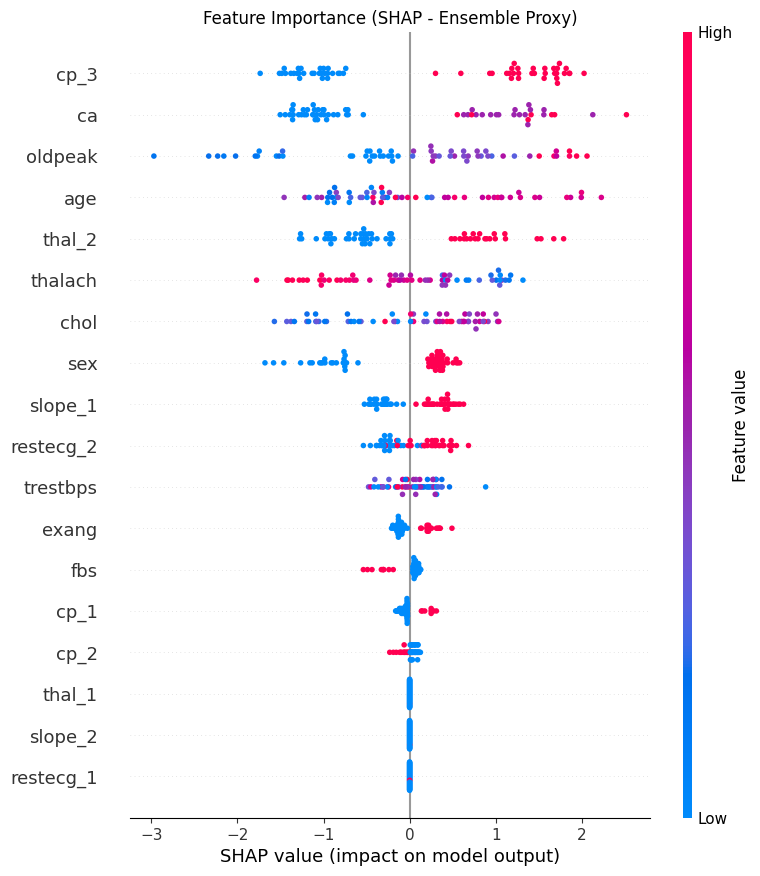


Generating LIME Explanation...


/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

In [ ]:
# --- Step 6: Explainability (Fixed for Crash) ---

import shap
import lime
import lime.lime_tabular

# --- Part A: SHAP (Global Proxy Explanation) ---
# We explain the XGBoost component as a proxy for the ensemble
# This avoids the crash because XGBoost handles raw arrays better
print("\nGenerating SHAP Summary Plot...")

# We access the fitted XGBoost model from inside the Stack
# 'base_estimators_' contains the fitted models. Index 2 is XGBoost (0=LR, 1=RF, 2=XGB)
fitted_xgb = stacking_model.estimators_[2]

explainer = shap.TreeExplainer(fitted_xgb)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure()
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.title("Feature Importance (SHAP - Ensemble Proxy)")
plt.show()

# --- Part B: LIME (Local Explanation) ---
# This was crashing. We fix it with a 'proba_wrapper'.

print("\nGenerating LIME Explanation...")

# 1. Define a Wrapper Function
# This takes the raw numbers from LIME, turns them back into a DataFrame with column names,
# and THEN asks the model for predictions.
def proba_wrapper(numpy_data):
    # Convert back to DataFrame using the original column names
    df_data = pd.DataFrame(numpy_data, columns=X_train_scaled.columns)
    return stacking_model.predict_proba(df_data)

# 2. Setup LIME Explainer
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled), # LIME wants numpy array for training data
    feature_names=X_train_scaled.columns,   # But we give it the names here
    class_names=['No Disease', 'Disease'],
    mode='classification'
)

# 3. Pick a specific patient (e.g., Index 28 which corresponds to Row 6 of test set)
target_idx = 6
# Double check this index exists in your test set size!
if target_idx >= len(X_test_scaled):
    target_idx = 0 # Fallback if index is too high

# 4. Generate Explanation using the WRAPPER
exp = explainer_lime.explain_instance(
    data_row=X_test_scaled.iloc[target_idx],
    predict_fn=proba_wrapper # <--- Use the wrapper here!
)

# 5. Show
exp.show_in_notebook(show_table=True)

# Step 6c: VERIFICATION of XAI

In [ ]:
# --- Step 6c: Verification ---

print(f"--- Patient Verification (Index {target_idx}) ---")

# Get actual label
actual_val = y_test.iloc[target_idx]
print(f"Actual Condition: {'Disease (1)' if actual_val == 1 else 'No Disease (0)'}")

# Get prediction
pred_val = stacking_model.predict(X_test_scaled.iloc[[target_idx]])[0]
print(f"Model Prediction: {'Disease (1)' if pred_val == 1 else 'No Disease (0)'}")

print("\n--- Patient Data ---")
print(X_test.iloc[target_idx])

--- Patient Verification (Index 6) ---
Actual Condition: Disease (1)
Model Prediction: Disease (1)

--- Patient Data ---
age             62
sex              1
trestbps       120
chol           281
fbs              0
thalach        103
exang            0
oldpeak        1.4
ca               1
cp_1          True
cp_2         False
cp_3         False
restecg_1    False
restecg_2     True
slope_1       True
slope_2      False
thal_1       False
thal_2        True
Name: 28, dtype: object
